# Augmented classifier: training, testing, running

Same pipeline as `baseline.ipynb` — fine-tunes Ultralytics YOLO
classification (`yolo26n-cls.pt`) on SID-Set for real vs
AI-generated/tampered — but trains on **realistically degraded** images
instead of clean ones.

It still drives everything through the shared classes in
`packages/models/normal_classifier`:

- **Training + testing** — `NormalClassifierTrainer`
  (`shared_types.TrainableModel`: `.train()` / `.evaluate()` / `.save()` / `.load()`).
- **Running (inference)** — `NormalClassifierDetector`
  (`shared_types.EnsembleDetector.predict()`), the same "ready" contract
  `apps/web` consumes.

The only difference from the baseline is the data source:
`data.dataset_builder.augmented_sid_dataset()`, a re-iterable stream over
SID-Set that

- pulls a balanced subset from Hugging Face **without downloading the whole
  dataset** — one decoded image is in memory at a time;
- runs every training image through the data package's `ImageAugmenter`
  (JPEG compression, blur, resize, noise, colour jitter, centre crop), so
  the model learns to see through the degradation real uploads pick up;
- re-streams on each iteration, so one object backs `train()`'s validation
  pass, `evaluate()` and the inference demo (seed-deterministic — every
  pass sees the same images).

The held-out set is streamed **clean** (`augment=False`) so metrics measure
generalisation rather than robustness to a fixed corruption; flip it to
`augment=True` if you want the latter.


## 1. Setup — clone the repo, install deps, wire up imports

In [1]:
%cd /content/
!git clone https://github.com/Zhongbob/TikTokTechJam2026.git

/content
Cloning into 'TikTokTechJam2026'...
remote: Enumerating objects: 820, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 820 (delta 14), reused 46 (delta 10), pack-reused 758 (from 1)
Receiving objects: 100% (820/820), 38.67 MiB | 32.59 MiB/s, done.
Resolving deltas: 100% (260/260), done.


In [2]:
%cd /content/TikTokTechJam2026
!git switch "autoencoder"
!git stash
!git pull
!curl -LsSf https://astral.sh/uv/install.sh | sh
import os,sys
os.environ["PATH"] += f":{os.path.expanduser('~/.local/bin')}"
%cd /content/TikTokTechJam2026/packages/models/autoencoder
!uv sync


/content/TikTokTechJam2026
Branch 'autoencoder' set up to track remote branch 'autoencoder' from 'origin'.
Switched to a new branch 'autoencoder'
No local changes to save
Already up to date.
downloading uv 0.12.7 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!
/content/TikTokTechJam2026/packages/models/autoencoder
Using CPython 3.13.15 interpreter at: /usr/bin/python3
Creating virtual environment at: /content/TikTokTechJam2026/.venv
Resolved 134 packages in 867ms
Prepared 70 packages in 30.80s
Installed 70 packages in 224ms
 + aiohappyeyeballs==2.7.1
 + aiohttp==3.14.3
 + aiosignal==1.4.0
 + anyio==4.14.2
 + attrs==26.1.0
 + autoencoder==0.1.0 (from file:///content/TikTokTechJam2026/packages/models/autoencoder)
 + boto3==1.43.83
 + botocore==1.43.83
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + click==8.5.0
 + cuda-bindings==13.3.1
 + cuda-pathfinder==1.8.0
 + cuda-toolkit==13.0.3.0
 + data==0.1.0 (from file:///content/TikTokTechJam2026/

In [ ]:
!uv pip install --system /content/TikTokTechJam2026/packages/data
# Might need to install local packages manually if the above doesnt work

# RESTART SESSION UNDER RUNTIME AFTER COMPLETING THE ABOVE

Using Python 3.13.15 environment at: /usr
Resolved 45 packages in 101ms
Prepared 1 package in 334ms
Uninstalled 1 package in 2ms
Installed 8 packages in 59ms
 + boto3==1.43.83
 + botocore==1.43.83
 + data==0.1.0 (from file:///content/TikTokTechJam2026/packages/data)
 + image-io==0.1.0 (from file:///content/TikTokTechJam2026/libs/image_io)
 + jmespath==1.1.0
 + s3transfer==0.19.2
 + shared-types==0.1.0 (from file:///content/TikTokTechJam2026/libs/shared_types)
 - tqdm==4.67.3
 + tqdm==4.70.0


In [1]:
# Run this AFTER restarting the session (cell above). Locates the .venv
# `uv sync` created and bridges its site-packages into this fresh kernel
# process via site.addsitedir() -- the API that actually processes uv's
# editable-install ".pth" redirects; a plain sys.path.insert() does not.
import glob
import importlib
import site
from pathlib import Path

candidates = [
    Path("/content/TikTokTechJam2026/.venv"),
    Path("/content/TikTokTechJam2026/packages/models/autoencoder/.venv"),
]
venv_dir = next((c for c in candidates if c.is_dir()), None)
if venv_dir is None:
    found = glob.glob("/content/TikTokTechJam2026/**/.venv", recursive=True)
    assert found, "no .venv found under the repo -- did `uv sync` in the cell above actually succeed?"
    venv_dir = Path(found[0])

site_packages = next(venv_dir.glob("lib/python*/site-packages"))
print(f"bridging {site_packages}")
site.addsitedir(str(site_packages))

importlib.invalidate_caches()
importlib.import_module("autoencoder")
print("'autoencoder' imported OK")


bridging /content/TikTokTechJam2026/.venv/lib/python3.13/site-packages
'autoencoder' imported OK


In [2]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Device Name: NVIDIA A100-SXM4-80GB


## 2. Stream augmented training + clean validation data from SID-Set

In [3]:
import inspect
from data.dataset_builder import autoencoder_dataset



# Get the function signature
signature = inspect.signature(autoencoder_dataset)

# Option A: Print the entire signature format
print(signature)
# Output: (name, age, country='USA', *args, **kwargs)

# Option B: Print just a list of the parameter names
print(list(signature.parameters.keys()))

(images_per_label: 'int', seed: 'int' = 4, buffer_size: 'int' = 100, split: 'str' = 'train', hf_token: 'str | None' = None, *, augment: 'bool' = True, num_augmentations: 'int | tuple[int, int]' = 6, variants_per_image: 'int' = 1, output_size: 'tuple[int, int] | None' = None, backend: 'str' = 'thread', num_workers: 'int | None' = None, prefetch: 'int | None' = None, cache_dir: 'str | os.PathLike[str] | None' = None, progress: 'bool' = True) -> 'AutoencoderDataset'
['images_per_label', 'seed', 'buffer_size', 'split', 'hf_token', 'augment', 'num_augmentations', 'variants_per_image', 'output_size', 'backend', 'num_workers', 'prefetch', 'cache_dir', 'progress']


In [19]:
import os

from data.dataset_builder import autoencoder_dataset
from google.colab import userdata

# Both are re-iterable, memory-bounded streams. Two speed-ups over a plain
# stream:
#   * backend="thread" (default) augments images across worker threads -- the
#     Pillow/NumPy transforms release the GIL, so this parallelises without
#     pickling every image. Results are still yielded in order. (Use
#     backend="process" instead if you have many CPU cores.)
#   * cache_dir -> the first pass writes each resized *clean* image to local
#     disk; every later pass (train's val pass, evaluate(), re-runs, and
#     baseline.ipynb's clean sets) reads from disk instead of Hugging Face.
#     Augmentation is still applied fresh on each read.
WORKERS = os.cpu_count()

# Training stream: each image gets a random 2-5 of the data package's six
# corruptions (JPEG, blur, resize, noise, colour jitter, crop).
train_samples = autoencoder_dataset(
    images_per_label=20000, split="train",
    num_augmentations=(1, 5), output_size=(224, 224),
    variants_per_image=3,
    num_workers=WORKERS, cache_dir="sid_cache",
    hf_token=userdata.get("HUGGING_FACE"),
    buffer_size=32
)

# Validation stream: same source, left clean (augment=False). Shares the
# sid_cache/ entry with baseline.ipynb.
val_samples = autoencoder_dataset(
    images_per_label=2000, split="validation",
    num_augmentations=(1, 5), output_size=(224, 224), cache_dir="sid_cache",
    hf_token=userdata.get("HUGGING_FACE"),
    buffer_size=32
)

print(f"train: {train_samples}  (~{len(train_samples)} samples)")
print(f"val:   {val_samples}  (~{len(val_samples)} samples)")


train: AutoencoderDataset(split='train', per_label=20000, augment 1-5 (thread), x3 variants, output_size=(224, 224), cache=cold)  (~240000 samples)
val:   AutoencoderDataset(split='validation', per_label=2000, augment 1-5 (thread), output_size=(224, 224), cache=cold)  (~12000 samples)


In [20]:
# Warm the disk cache up front. This is the slow part -- one streaming pass
# over Hugging Face -- and it gets its own progress bar so you can see the
# throughput (img/s) and whether the network is the bottleneck. After this,
# train() and evaluate() read images from sid_cache/ instead of the network.
#
# The bar sits at 0 for a bit first while HF fills its shuffle buffer; pass
# buffer_size=32 to augmented_sid_dataset(...) above to shorten that.
train_samples.warm_cache()
val_samples.warm_cache()


SID train (caching, HF stream):   0%|          | 0/240000 [00:00<?, ?img/s]

  train: streaming from HuggingFace -- the first ~32 images fill the shuffle buffer before the bar moves. Pass a smaller buffer_size= to shorten this.


Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/249 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

PosixPath('sid_cache/sid-validation-2000pl-seed4-buf32-raw')

## 3. Train

`NormalClassifierTrainer.train()` exports `train_samples`/`val_samples` into
the `real/`, `ai_generated/` class-folder layout Ultralytics' classification
trainer expects, then fine-tunes `yolo26n-cls.pt` on them. Each source image
is augmented as it is streamed, then written once and reused across epochs.

In [21]:
from autoencoder import AutoencoderTrainer

trainer = AutoencoderTrainer()
result = trainer.train(
    train_samples,
    val_samples=val_samples,
    output_dir="SID_YOLO_AUG",
    epochs=20,
    batch=32,
    patience=10,
    device="cuda:0",
    plots=True,
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3
)
result


SID train (autoencoder, disk cache):   0%|          | 0/240000 [00:00<?, ?img/s]

SID validation (autoencoder, disk cache):   0%|          | 0/12000 [00:00<?, ?img/s]

epoch=1/20 train_loss=0.004698 val_loss=0.003705
epoch=2/20 train_loss=0.003680 val_loss=0.003347
epoch=3/20 train_loss=0.003546 val_loss=0.002862
epoch=4/20 train_loss=0.003480 val_loss=0.002704
epoch=5/20 train_loss=0.003445 val_loss=0.002750
epoch=6/20 train_loss=0.003414 val_loss=0.002652
epoch=7/20 train_loss=0.003396 val_loss=0.002787
epoch=8/20 train_loss=0.003381 val_loss=0.002634
epoch=9/20 train_loss=0.003370 val_loss=0.002523
epoch=10/20 train_loss=0.003358 val_loss=0.002704
epoch=11/20 train_loss=0.003351 val_loss=0.002608
epoch=12/20 train_loss=0.003347 val_loss=0.002772
epoch=13/20 train_loss=0.003335 val_loss=0.002641
epoch=14/20 train_loss=0.003326 val_loss=0.002553
epoch=15/20 train_loss=0.003324 val_loss=0.002622
epoch=16/20 train_loss=0.003318 val_loss=0.002558
epoch=17/20 train_loss=0.003316 val_loss=0.002531
epoch=18/20 train_loss=0.003306 val_loss=0.002593
epoch=19/20 train_loss=0.003302 val_loss=0.002513
epoch=20/20 train_loss=0.003302 val_loss=0.002525


TrainingResult(epochs_completed=20, final_loss=0.002512758586167668, metrics={'train_loss': 0.003302300813072361, 'val_loss': 0.002512758586167668}, checkpoint_path='SID_YOLO_AUG/autoencoder_best.pt', notes='Trained on 240000 paired samples and validated on 12000.')

## 4. Test

The "testing" stage — score the trained model against a held-out set via
`.evaluate()`. SID-Set only exposes train/validation splits, so this
re-iterates `val_samples` (which re-streams from Hugging Face, still clean);
swap in a separate held-out set here if you have one.


In [22]:
metrics = trainer.evaluate(val_samples, output_dir="SID_YOLO_AUG_eval")
print("Held-out evaluation metrics:", metrics)


SID validation (autoencoder, disk cache):   0%|          | 0/12000 [00:00<?, ?img/s]

Held-out evaluation metrics: {'mse': 0.002524630920573448, 'rmse': 0.050245705493837466}


In [23]:
trainer.save("autoencoder.pt")
print("Saved checkpoint to autoencoder.pt")

Saved checkpoint to autoencoder.pt


## 5. Run (inference)

The "running" stage — `NormalClassifierDetector` wraps the saved checkpoint
and implements the same `EnsembleDetector` contract `apps/web` consumes, so
this class can be dropped straight into
`apps/web/src/web/services/factory.py`'s `get_detector()` once ready.

In [24]:
import itertools

from autoencoder import AutoencoderRestorer

restorer = AutoencoderRestorer.from_checkpoint("SID_YOLO_AUG/autoencoder_best.pt")

# val_samples re-streams on iteration; islice pulls just the first 5, so only
# those 5 images are ever decoded here.
restorer.evaluate(val_samples)


SID validation (autoencoder, disk cache):   0%|          | 0/12000 [00:00<?, ?img/s]

{'mse': 0.002512841791147366, 'rmse': 0.05012825342207093}

SID validation (autoencoder, disk cache):   0%|          | 0/12000 [00:00<?, ?img/s]

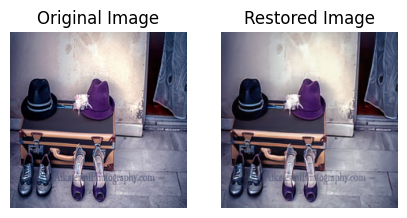

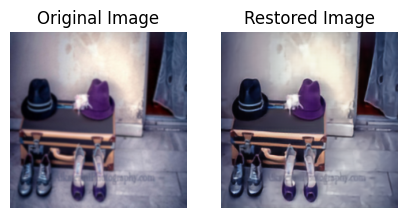

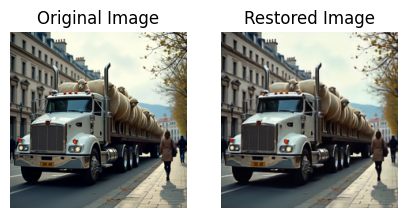

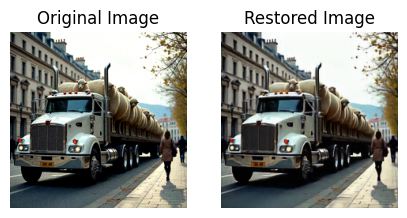

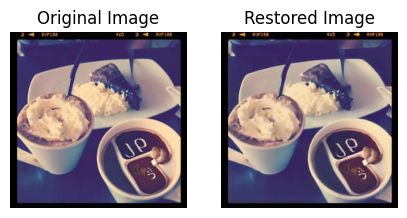

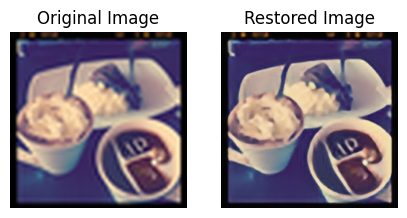

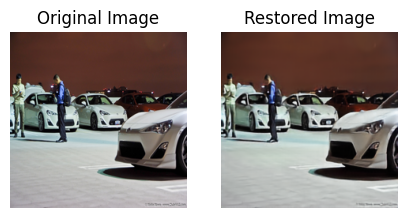

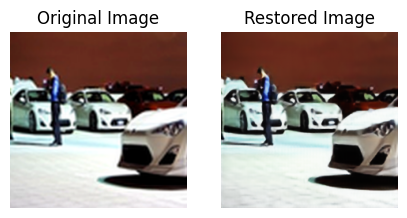

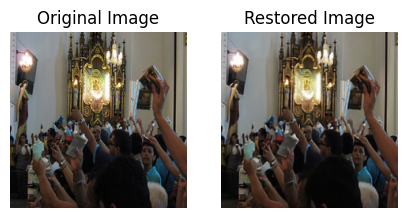

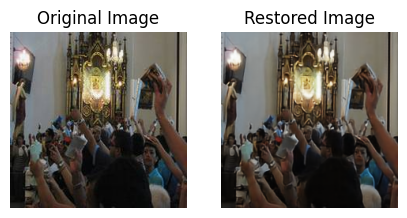

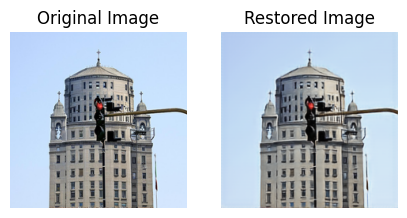

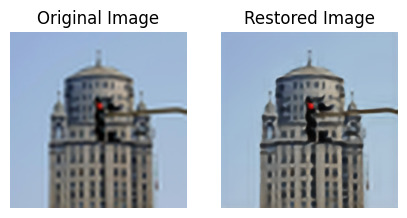

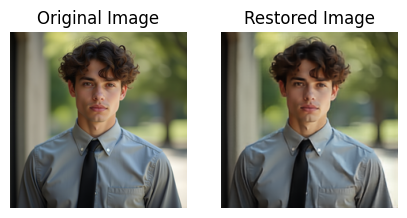

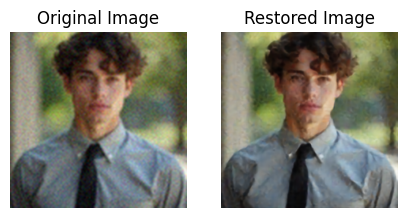

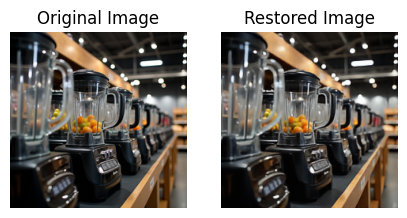

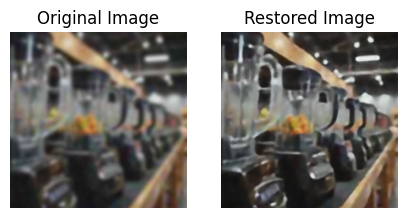

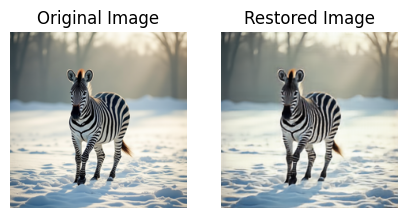

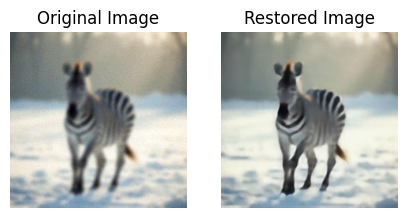

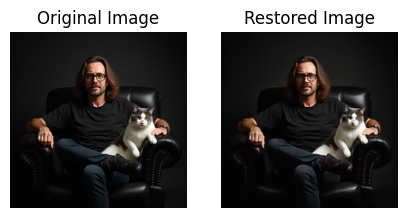

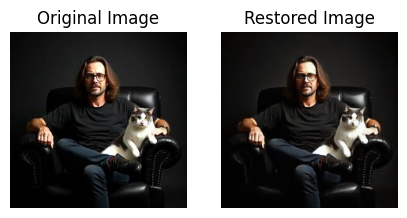

In [25]:
import matplotlib.pyplot as plt
import torch
from torchvision import transforms


sample_num = 10
count = 0

# Get the first elements from val_samples
# autoencoder_dataset yields ImagePairSample objects, which contain input_image and target_image
for sample in iter(val_samples):
  count += 1
  if count > sample_num * 2:
    break
  original_pil_image = sample.input_image # This is likely a PIL Image

  # Convert PIL Image to PyTorch tensor for display and internal use after restorer
  transformer = transforms.ToTensor()
  original_image_tensor = transformer(original_pil_image)

  # Display the original image
  plt.figure(figsize=(5, 2.5))
  plt.subplot(1, 2, 1)
  plt.title("Original Image")
  # Assuming image_tensor is a PyTorch tensor (C, H, W), convert to (H, W, C) for matplotlib
  # and move to CPU, then convert to numpy
  plt.imshow(original_image_tensor.permute(1, 2, 0).cpu().numpy())
  plt.axis('off')

  # Pass the original image to the restorer
  # Convert the PyTorch tensor back to a PIL Image, as restorer.predict expects a PIL Image
  to_pil_image = transforms.ToPILImage()
  original_image_for_predict = to_pil_image(original_image_tensor)

  with torch.no_grad():
      restored_pil_image = restorer.predict(original_image_for_predict)

  # Convert the restored PIL Image to a PyTorch tensor for display
  restored_image_tensor = transformer(restored_pil_image)

  # Display the restored image
  plt.subplot(1, 2, 2)
  plt.title("Restored Image")
  # Convert to (H, W, C) for matplotlib, move to CPU, then convert to numpy
  plt.imshow(restored_image_tensor.permute(1, 2, 0).cpu().numpy())
  plt.axis('off')

  plt.show()